In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Load the preprocessed dataset from Step 1
# Ensure the file name matches what you saved in the previous notebook
try:
    df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MAI391_Project/hcm_weather_preprocessed.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    print("Data loaded successfully! Shape:", df.shape)
except FileNotFoundError:
    print("Error: Could not find '/content/drive/MyDrive/Colab Notebooks/MAI391_Project/hcm_weather_preprocessed.csv'. Please run the Step 1 notebook first.")

# Display available columns to verify
display(df.head())

Data loaded successfully! Shape: (4371, 14)


,Date,Temp,Feels,Wind,Gust,Rain,Humidity,Cloud,Pressure,Vis,Weather,Month,Weather_Label,Target_Next_Day_Label
0,2009-01-01,-1.923132,-1.701444,-0.783004,-0.582932,0.266762,1.495584,1.884732,0.499568,NaN,Cloudy,1,1,1.0
1,2009-01-02,-2.210531,-2.538639,0.064763,0.268309,-0.550304,0.869939,1.112285,0.800566,NaN,Cloudy,1,1,13.0
2,2009-01-03,-3.144580,-3.323509,-0.967301,-0.789294,-0.213865,1.315109,1.356563,1.101563,NaN,Partly cloudy,1,13,13.0
3,2009-01-04,-2.569781,-2.800262,-1.483333,-1.356788,-0.566325,0.845875,0.115367,0.981164,NaN,Partly cloudy,1,13,13.0
4,2009-01-05,-1.707582,-1.858418,-1.262176,-1.253608,-0.566325,0.256325,-0.544844,0.740366,NaN,Partly cloudy,1,13,17.0


/tmp/ipykernel_194/2258359920.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Temp', data=df, palette='Set3', showmeans=True,


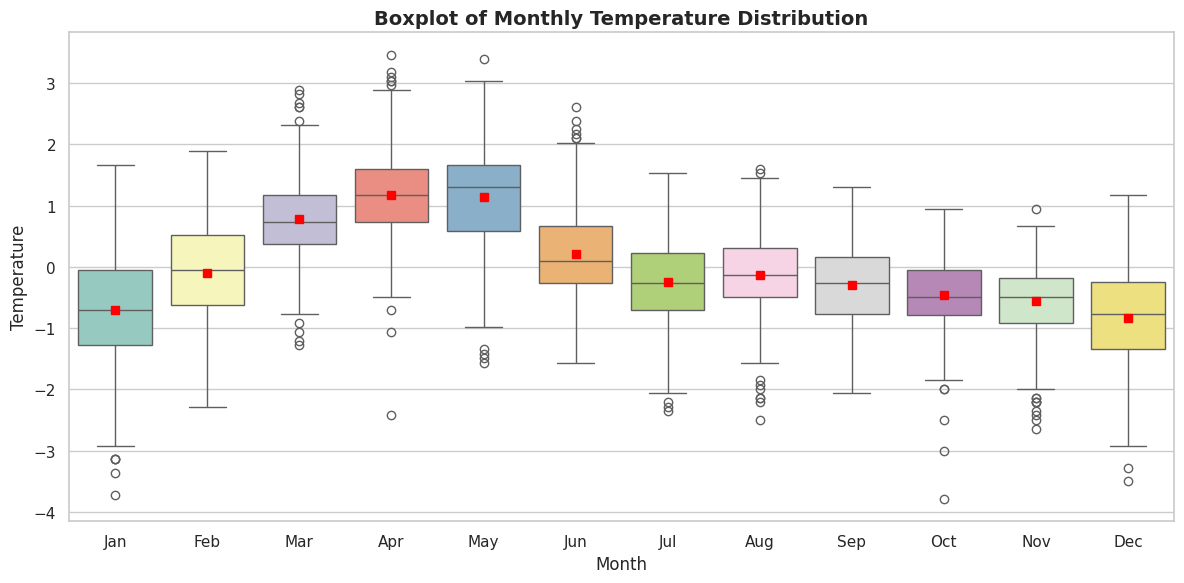

In [2]:
plt.figure(figsize=(12, 6))

# In your dataset, 'Temp' represents the temperature.
# We group by the 'Month' feature created in Step 1.
sns.boxplot(x='Month', y='Temp', data=df, palette='Set3', showmeans=True,
            meanprops={"marker":"s","markerfacecolor":"red", "markeredgecolor":"red"})

plt.title('Boxplot of Monthly Temperature Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Temperature', fontsize=12)

# Set custom x-axis labels for months
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks=range(0, 12), labels=months)

plt.tight_layout()
plt.show()

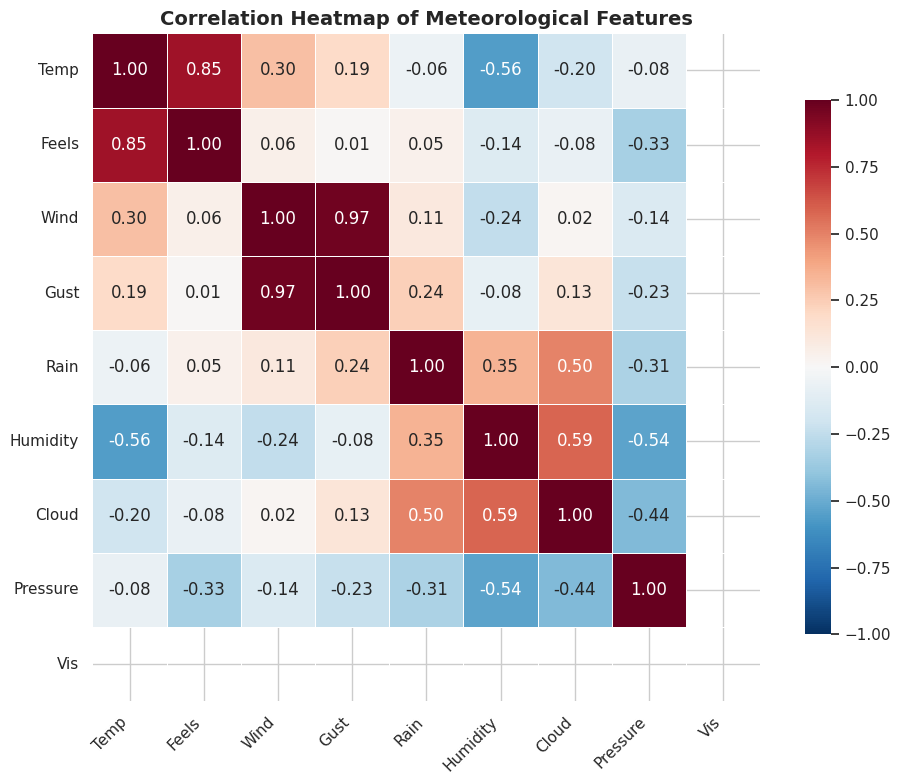

In [3]:
plt.figure(figsize=(10, 8))

# Select only the numeric columns for correlation
numeric_cols = ['Temp', 'Feels', 'Wind', 'Gust', 'Rain', 'Humidity', 'Cloud', 'Pressure', 'Vis']
corr_matrix = df[numeric_cols].corr()

# Create a mask to show only the lower triangle (optional, for cleaner look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Meteorological Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_194/2897285846.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Rain', data=monthly_rain, palette='Blues')


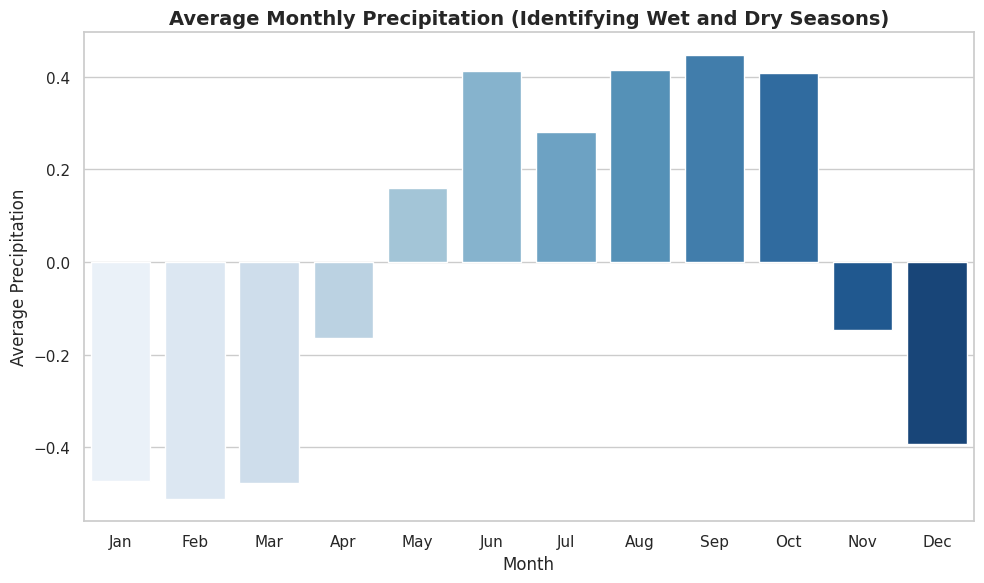

In [4]:
plt.figure(figsize=(10, 6))

# Calculate average precipitation per month
monthly_rain = df.groupby('Month')['Rain'].mean().reset_index()

# Plot using a bar chart with a sequential color palette
sns.barplot(x='Month', y='Rain', data=monthly_rain, palette='Blues')

plt.title('Average Monthly Precipitation (Identifying Wet and Dry Seasons)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Precipitation', fontsize=12)

# Set custom x-axis labels
plt.xticks(ticks=range(0, 12), labels=months)

plt.tight_layout()
plt.show()